In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mahotas

print("Computer vision environment is ready.")

Computer vision environment is ready.


# Object Extraction Using Thresholding Techniques

This notebook demonstrates how to extract objects from homogeneous backgrounds using image thresholding techniques.

Two input images are analyzed:

- A mango placed on a homogeneous background.
- A cup placed on a homogeneous background.

The notebook compares different thresholding methods and uses the best resulting binary mask to extract each object from its background.

In [12]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import mahotas

In [13]:
# Define the project directories
project_dir = Path.cwd()
input_dir = project_dir / "input_images"
output_dir = project_dir / "output_images"

# Define the input image paths
mango_path = input_dir / "image1_mango.jpeg"
cup_path = input_dir / "image2_cup.jpeg"

print(f"Project directory: {project_dir}")
print(f"Mango image exists: {mango_path.exists()}")
print(f"Cup image exists: {cup_path.exists()}")

Project directory: /Users/mateocordoba/dev/college/machine_learning_ii/assignments/thresholding_object_extraction
Mango image exists: True
Cup image exists: True


In [14]:
# Load the images using OpenCV
mango_bgr = cv2.imread(str(mango_path))
cup_bgr = cv2.imread(str(cup_path))

# Validate that both images were loaded successfully
if mango_bgr is None:
    raise FileNotFoundError(f"Could not load the image: {mango_path}")

if cup_bgr is None:
    raise FileNotFoundError(f"Could not load the image: {cup_path}")

print(f"Mango image shape: {mango_bgr.shape}")
print(f"Cup image shape: {cup_bgr.shape}")

Mango image shape: (1600, 1200, 3)
Cup image shape: (1600, 1200, 3)


## Convert Images to RGB and Grayscale

OpenCV loads images in BGR format, so they are converted to RGB for correct visualization. Grayscale versions are also created because thresholding techniques work on pixel intensity values.

In [15]:
# Convert the images from BGR to RGB for correct Matplotlib visualization
mango_rgb = cv2.cvtColor(mango_bgr, cv2.COLOR_BGR2RGB)
cup_rgb = cv2.cvtColor(cup_bgr, cv2.COLOR_BGR2RGB)

# Convert the images to grayscale for thresholding
mango_gray = cv2.cvtColor(mango_bgr, cv2.COLOR_BGR2GRAY)
cup_gray = cv2.cvtColor(cup_bgr, cv2.COLOR_BGR2GRAY)

print("RGB and grayscale versions were created successfully.")

RGB and grayscale versions were created successfully.


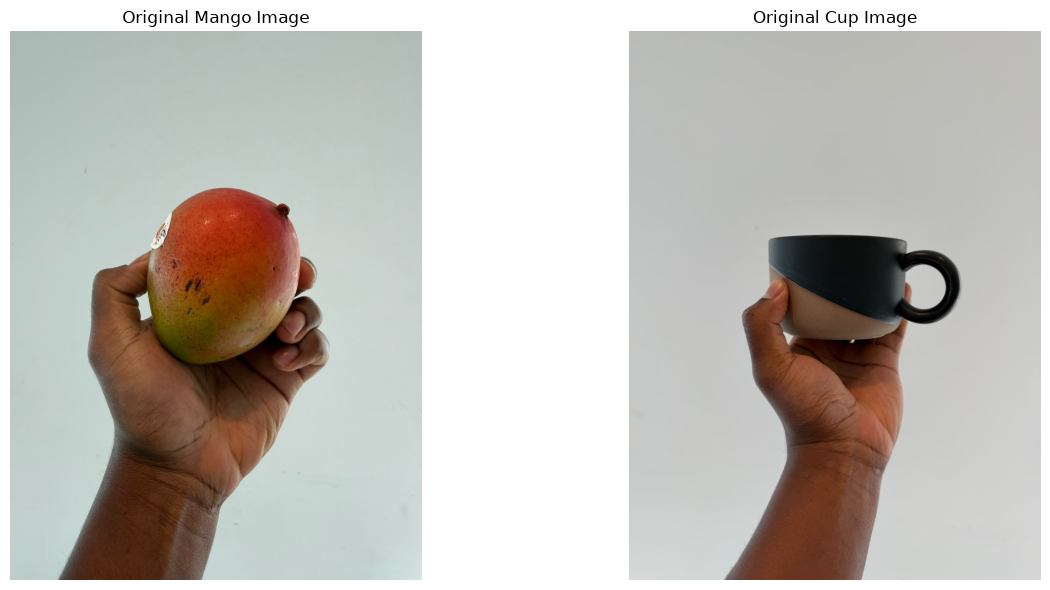

In [16]:
# Display the original input images
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(mango_rgb)
plt.title("Original Mango Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cup_rgb)
plt.title("Original Cup Image")
plt.axis("off")

plt.tight_layout()
plt.show()

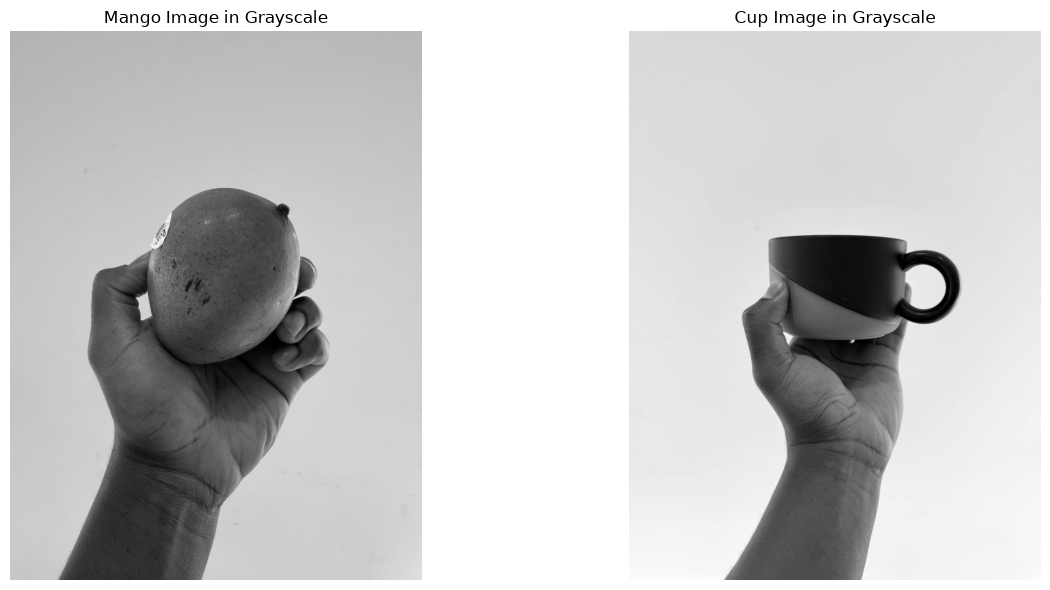

In [17]:
# Display the grayscale images used for thresholding
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(mango_gray, cmap="gray")
plt.title("Mango Image in Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cup_gray, cmap="gray")
plt.title("Cup Image in Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

## Apply Gaussian Smoothing

Gaussian smoothing reduces small intensity variations and image noise before thresholding. This helps produce cleaner binary masks while preserving the main shape of each object.

In [18]:
# Apply Gaussian smoothing to reduce noise before thresholding
mango_blurred = cv2.GaussianBlur(mango_gray, (5, 5), 0)
cup_blurred = cv2.GaussianBlur(cup_gray, (5, 5), 0)

print("Gaussian smoothing was applied successfully.")

Gaussian smoothing was applied successfully.


## Display the Smoothed Images

The smoothed grayscale images are displayed to verify that small details and noise were reduced without significantly affecting the object boundaries.

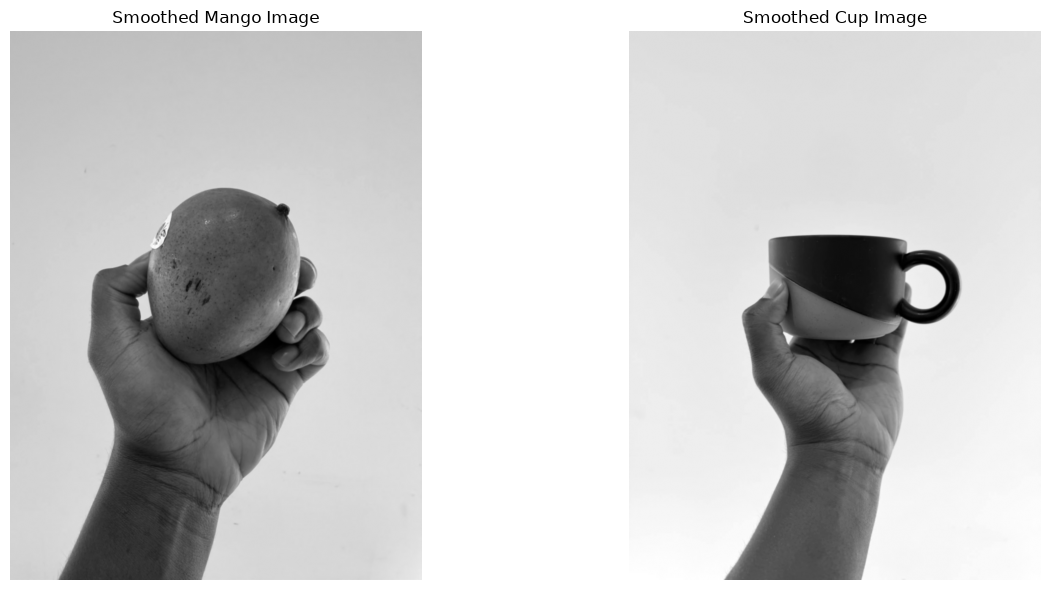

In [19]:
# Display the smoothed grayscale images
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(mango_blurred, cmap="gray")
plt.title("Smoothed Mango Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cup_blurred, cmap="gray")
plt.title("Smoothed Cup Image")
plt.axis("off")

plt.tight_layout()
plt.show()

## Analyze Pixel Intensity Histograms

The grayscale histograms show how pixel intensities are distributed in each image. This information helps identify possible threshold values for separating the objects from their backgrounds.

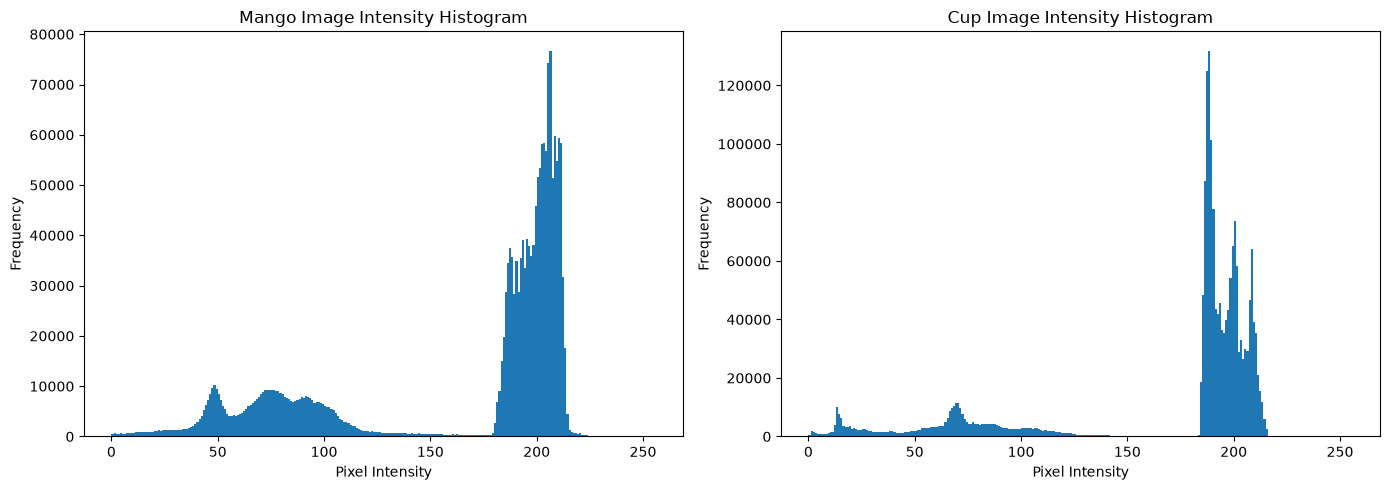

In [20]:
# Display grayscale intensity histograms
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(mango_blurred.ravel(), bins=256, range=(0, 256))
plt.title("Mango Image Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(cup_blurred.ravel(), bins=256, range=(0, 256))
plt.title("Cup Image Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Compare Simple Threshold Values

Simple thresholding converts each grayscale image into a binary mask using a manually selected threshold value. Several values are tested to identify which one provides the clearest separation between the object and the background.

In [21]:
def compare_thresholds(image, thresholds, image_name):
    """Display binary thresholding results for multiple threshold values."""
    
    plt.figure(figsize=(16, 8))

    for index, threshold_value in enumerate(thresholds):
        _, binary_image = cv2.threshold(
            image,
            threshold_value,
            255,
            cv2.THRESH_BINARY
        )

        plt.subplot(2, 2, index + 1)
        plt.imshow(binary_image, cmap="gray")
        plt.title(f"{image_name}: Threshold = {threshold_value}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

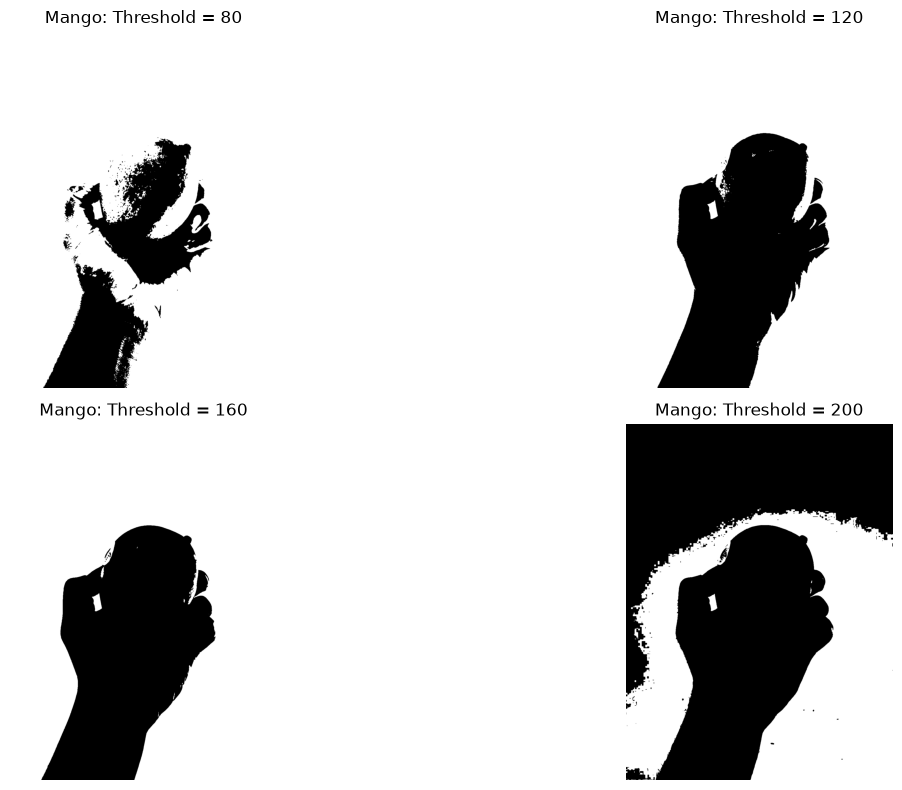

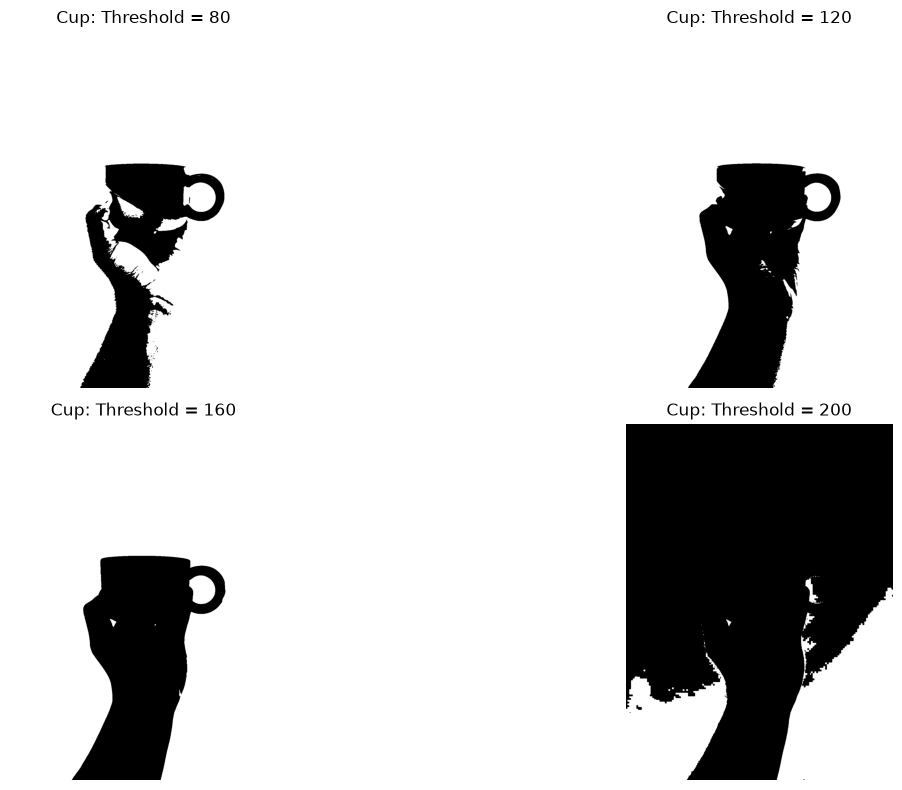

In [22]:
# Candidate threshold values for visual comparison
threshold_values = [80, 120, 160, 200]

compare_thresholds(
    mango_blurred,
    threshold_values,
    "Mango"
)

compare_thresholds(
    cup_blurred,
    threshold_values,
    "Cup"
)

## Apply the Selected Simple Threshold

A threshold value of 160 provided the clearest separation for both images. Binary and inverse binary thresholding are compared to determine which version produces the most suitable object mask.

In [23]:
# Apply simple binary and inverse binary thresholding
selected_threshold = 160

_, mango_binary = cv2.threshold(
    mango_blurred,
    selected_threshold,
    255,
    cv2.THRESH_BINARY
)

_, mango_binary_inv = cv2.threshold(
    mango_blurred,
    selected_threshold,
    255,
    cv2.THRESH_BINARY_INV
)

_, cup_binary = cv2.threshold(
    cup_blurred,
    selected_threshold,
    255,
    cv2.THRESH_BINARY
)

_, cup_binary_inv = cv2.threshold(
    cup_blurred,
    selected_threshold,
    255,
    cv2.THRESH_BINARY_INV
)

print("Simple thresholding was applied using a threshold value of 160.")

Simple thresholding was applied using a threshold value of 160.


## Compare Binary and Inverse Masks

The normal and inverse binary masks are displayed to identify which version represents the object in white and the background in black.

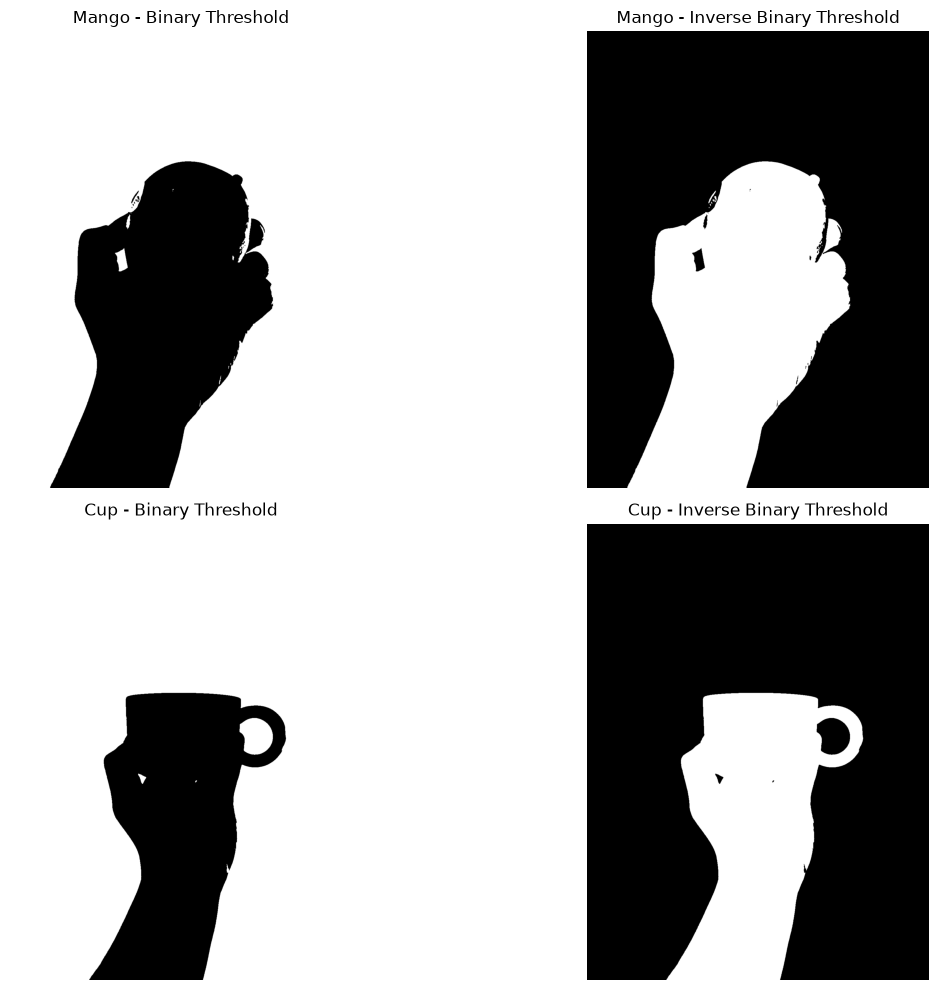

In [24]:
# Display the normal and inverse thresholding results
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(mango_binary, cmap="gray")
plt.title("Mango - Binary Threshold")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mango_binary_inv, cmap="gray")
plt.title("Mango - Inverse Binary Threshold")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cup_binary, cmap="gray")
plt.title("Cup - Binary Threshold")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cup_binary_inv, cmap="gray")
plt.title("Cup - Inverse Binary Threshold")
plt.axis("off")

plt.tight_layout()
plt.show()

## Extract the Objects Using the Selected Masks

The inverse binary masks provide the best separation for both images. These masks are applied to the original images to preserve the objects while removing the background.

In [25]:
# Select the inverse binary masks
mango_selected_mask = mango_binary_inv
cup_selected_mask = cup_binary_inv

# Apply the masks to the original images
mango_extracted_bgr = cv2.bitwise_and(
    mango_bgr,
    mango_bgr,
    mask=mango_selected_mask
)

cup_extracted_bgr = cv2.bitwise_and(
    cup_bgr,
    cup_bgr,
    mask=cup_selected_mask
)

# Convert the extracted images to RGB for visualization
mango_extracted_rgb = cv2.cvtColor(
    mango_extracted_bgr,
    cv2.COLOR_BGR2RGB
)

cup_extracted_rgb = cv2.cvtColor(
    cup_extracted_bgr,
    cv2.COLOR_BGR2RGB
)

print("The objects were extracted successfully.")

The objects were extracted successfully.


## Display the Extracted Objects

The extracted images show the portions of the original images selected by the binary masks. The background pixels are replaced with black.

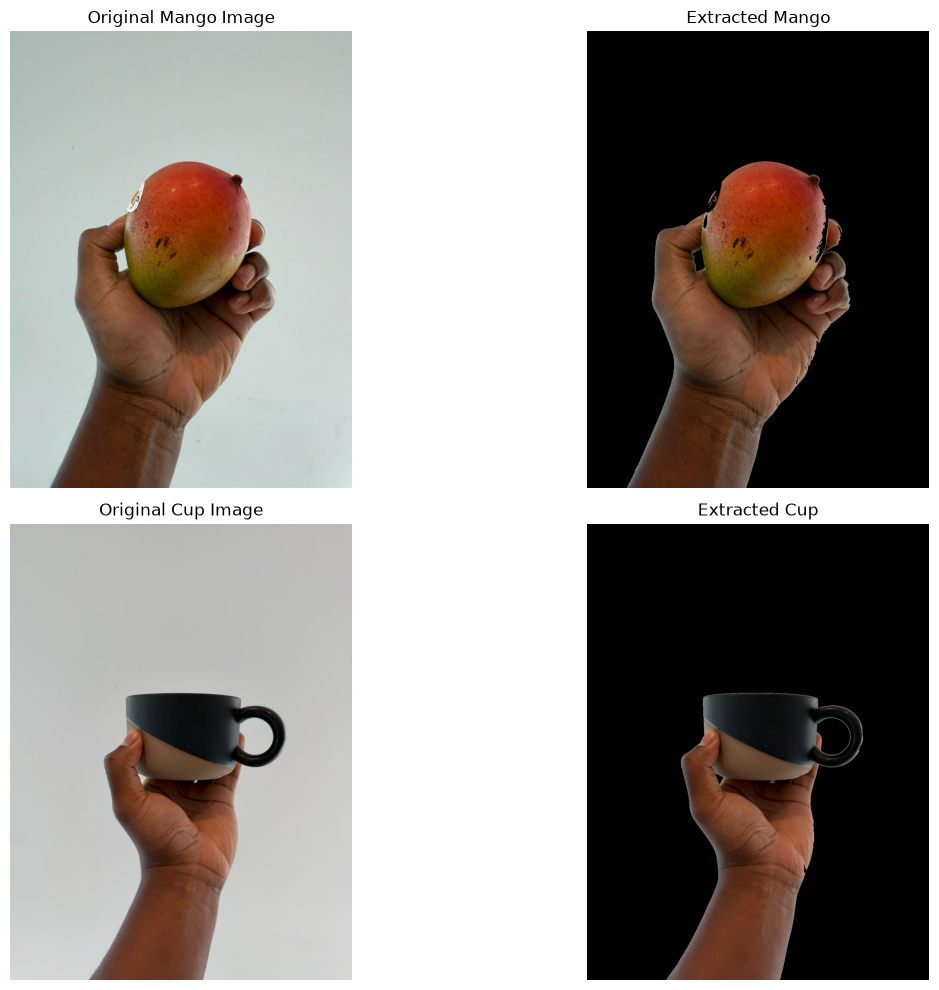

In [26]:
# Display the original and extracted images
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(mango_rgb)
plt.title("Original Mango Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mango_extracted_rgb)
plt.title("Extracted Mango")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cup_rgb)
plt.title("Original Cup Image")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cup_extracted_rgb)
plt.title("Extracted Cup")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# Create the output directory if it does not exist
output_dir.mkdir(parents=True, exist_ok=True)

# Define output file paths
mango_output_path = output_dir / "mango_extracted.jpg"
cup_output_path = output_dir / "cup_extracted.jpg"

mango_mask_path = output_dir / "mango_binary_mask.jpg"
cup_mask_path = output_dir / "cup_binary_mask.jpg"

# Save the extracted images
cv2.imwrite(
    str(mango_output_path),
    mango_extracted_bgr
)

cv2.imwrite(
    str(cup_output_path),
    cup_extracted_bgr
)

# Save the selected masks
cv2.imwrite(
    str(mango_mask_path),
    mango_selected_mask
)

cv2.imwrite(
    str(cup_mask_path),
    cup_selected_mask
)

print(f"Saved: {mango_output_path}")
print(f"Saved: {cup_output_path}")
print(f"Saved: {mango_mask_path}")
print(f"Saved: {cup_mask_path}")

Saved: /Users/mateocordoba/dev/college/machine_learning_ii/assignments/thresholding_object_extraction/output_images/mango_extracted.jpg
Saved: /Users/mateocordoba/dev/college/machine_learning_ii/assignments/thresholding_object_extraction/output_images/cup_extracted.jpg
Saved: /Users/mateocordoba/dev/college/machine_learning_ii/assignments/thresholding_object_extraction/output_images/mango_binary_mask.jpg
Saved: /Users/mateocordoba/dev/college/machine_learning_ii/assignments/thresholding_object_extraction/output_images/cup_binary_mask.jpg
